# LeetCode #156: Binary Tree Upside Down

https://leetcode.com/problems/binary-tree-upside-down/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Recursive** | $O(n)$ | $O(n)$ call stack |
| **Optimal: Iterative** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Recursive
Recurse to the leftmost node (this becomes the new root). On the way back up, rewire: the parent's left child's left becomes the parent's right child, and the left child's right becomes the parent itself. Clear the parent's children. The recursion stack uses $O(n)$ space.

### Optimal: Iterative ★
Walk down the left spine of the tree, keeping track of the current node, its parent, and the parent's right child. At each step:
1. Save `curr.left` as next.
2. Set `curr.left = parentRight` (parent's right child becomes current's left).
3. Set `curr.right = parent` (parent becomes current's right).
4. Move forward: `parent = curr`, `parentRight = savedRight`, `curr = next`.

When `curr` is null, `parent` is the new root.

**Key insight:** The leftmost leaf becomes the root. Each node's left child becomes that child's right, and each node's right sibling becomes the left child.

**Constraints:**
* Every right node has a sibling left node with no children, or is empty.
* The tree can be empty.

## Solutions

### C#

In [ ]:
// Definition for a binary tree node.
public class TreeNode {
    public int val;
    public TreeNode left;
    public TreeNode right;
    public TreeNode(int val = 0, TreeNode left = null, TreeNode right = null) {
        this.val = val;
        this.left = left;
        this.right = right;
    }
}

public class Solution {
    public TreeNode UpsideDownBinaryTree(TreeNode root) {
        TreeNode curr = root;
        TreeNode parent = null;
        TreeNode parentRight = null;
        
        while (curr != null) {
            TreeNode next = curr.left;
            TreeNode savedRight = curr.right;
            curr.left = parentRight;
            curr.right = parent;
            parent = curr;
            parentRight = savedRight;
            curr = next;
        }
        
        return parent;
    }
}

### Python

In [ ]:
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def upsideDownBinaryTree(self, root: TreeNode) -> TreeNode:
        curr = root
        parent = None
        parent_right = None
        
        while curr:
            next_left = curr.left
            saved_right = curr.right
            curr.left = parent_right
            curr.right = parent
            parent = curr
            parent_right = saved_right
            curr = next_left
        
        return parent

### Go

In [ ]:
// Definition for a binary tree node.
// type TreeNode struct {
//     Val   int
//     Left  *TreeNode
//     Right *TreeNode
// }

func upsideDownBinaryTree(root *TreeNode) *TreeNode {
    var parent, parentRight *TreeNode
    curr := root
    
    for curr != nil {
        next := curr.Left
        savedRight := curr.Right
        curr.Left = parentRight
        curr.Right = parent
        parent = curr
        parentRight = savedRight
        curr = next
    }
    
    return parent
}

### Rust

In [ ]:
// Definition for a binary tree node.
// #[derive(Debug, PartialEq, Eq)]
// pub struct TreeNode {
//     pub val: i32,
//     pub left: Option<Rc<RefCell<TreeNode>>>,
//     pub right: Option<Rc<RefCell<TreeNode>>>,
// }

use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn upside_down_binary_tree(
        root: Option<Rc<RefCell<TreeNode>>>,
    ) -> Option<Rc<RefCell<TreeNode>>> {
        let mut curr = root;
        let mut parent: Option<Rc<RefCell<TreeNode>>> = None;
        let mut parent_right: Option<Rc<RefCell<TreeNode>>> = None;
        
        while let Some(node) = curr {
            let next = node.borrow_mut().left.take();
            let saved_right = node.borrow_mut().right.take();
            node.borrow_mut().left = parent_right;
            node.borrow_mut().right = parent;
            parent = Some(node);
            parent_right = saved_right;
            curr = next;
        }
        
        parent
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `root = [1, 2, 3, 4, 5]`  
Walk down left spine: $1 \to 2 \to 4$. Node 4 (leftmost leaf) becomes new root. Rewire: $4.\text{left} = 5$ (parent's right), $4.\text{right} = 2$ (parent). Then $2.\text{left} = 3$, $2.\text{right} = 1$. Clear 1's children.  
WHY tricky: Must save `next` and `savedRight` BEFORE overwriting curr's pointers — order of operations is critical since rewiring destroys original links.  
**Output:** `[4, 5, 2, null, null, 3, 1]`

### 2. Slightly Complex
**Input:** `root = [1, 2, 3]`  
Left spine has 2 nodes: $1 \to 2$. Node 2 becomes new root. Rewire: $2.\text{left} = 3$ (parent 1's right child), $2.\text{right} = 1$ (parent). Clear 1's children. Result: $[2, 3, 1]$.  
WHY tricky: Minimal multi-node case. The right sibling becomes the left child and the parent becomes the right child — validates the core rewiring rule.  
**Output:** `[2, 3, 1]`

### 3. Edge Case: Time Factor
**Input:** Left-skewed tree with $n$ nodes, each with a right sibling  
Iterative approach walks the left spine once: $O(n)$ iterations. Each step does exactly 4 pointer assignments — constant-time work per node, no revisiting.  
WHY tricky: Each iteration does exactly 4 pointer operations. Strictly $O(n)$ with no hidden constant factors. Recursive approach would add stack overhead.  
**Output:** Reversed tree in $O(n)$ time

### 4. Edge Case: Space Factor
**Input:** Deep left-skewed tree with 10,000 nodes  
Iterative approach uses only 4 pointers: curr, parent, parentRight, and temporaries. Space is $O(1)$ regardless of tree size. Recursive approach would need $O(n) = O(10{,}000)$ stack frames.  
WHY tricky: Iterative achieves $O(1)$ space — the key advantage. With 10K nodes, recursive risks stack overflow ($\sim500$ KB stack frames vs $\sim40$ bytes for 4 pointers).  
**Output:** $O(1)$ space — only 4 pointers regardless of input size

### 5. Almost-Impossible but Plausible
**Input:** `root = null` (empty tree)  
The while loop condition `curr != null` is immediately false. Returns parent, which is still null. Zero iterations, zero pointer operations.  
WHY tricky: The constraint allows empty trees. The iterative approach naturally handles null with no special case — the loop body never executes.  
**Output:** `null`

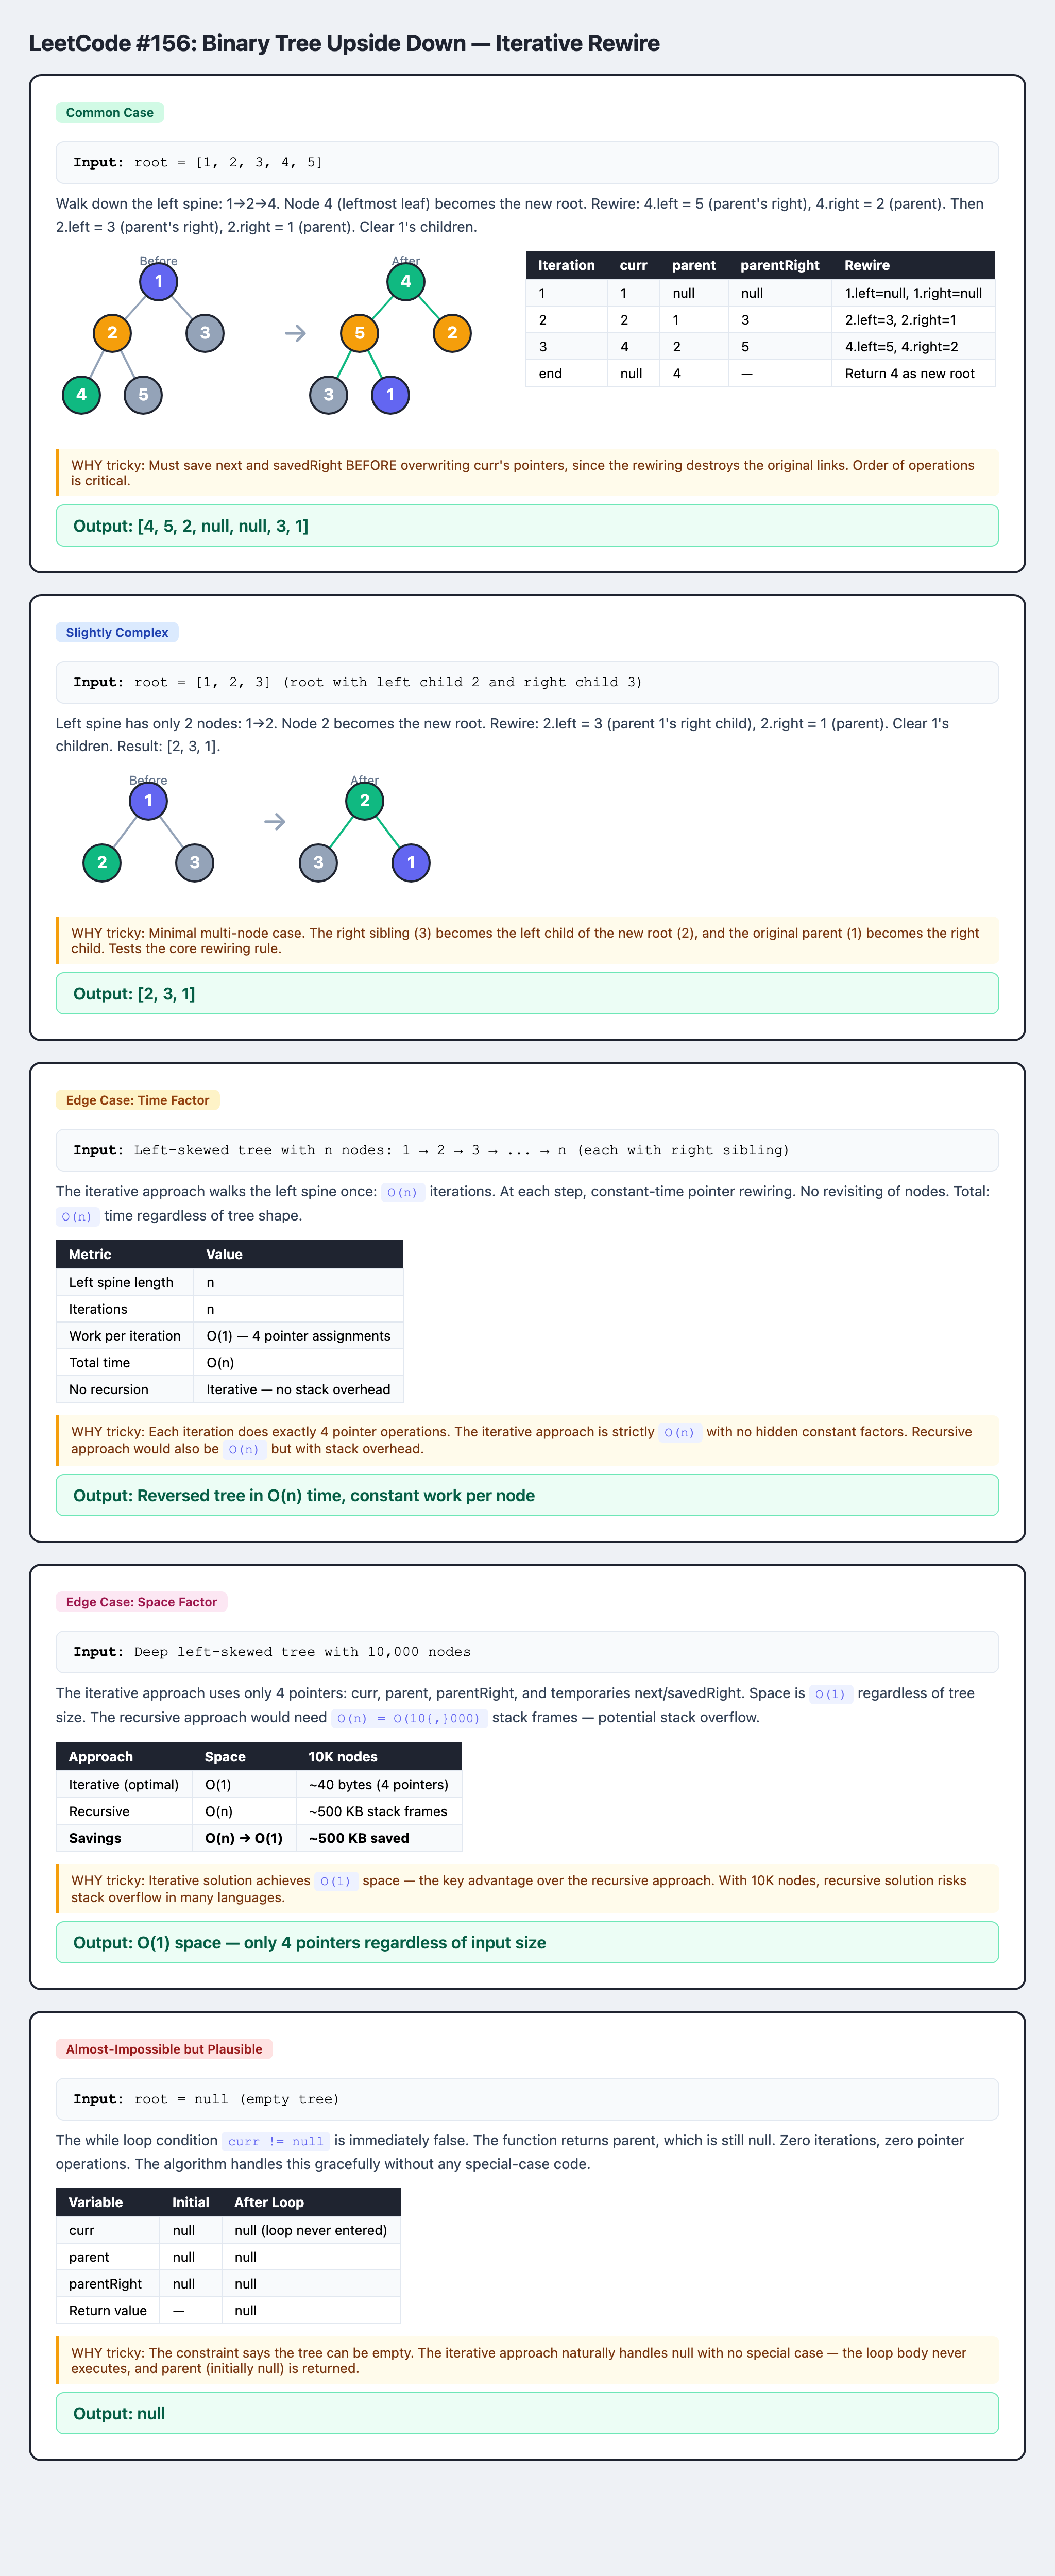